# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div>

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           69          |
|------------|----------------------|
| Luca Rowan Tuluș  |        6154875       |
| Szymon Krętowski  |        6128351       |
| Hristo Bozhkov  |        6142680       |
| Kamil Wawszczak  |        6160395       |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [16]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            return None

        idx = np.random.choice(len(valid_actions))
        return valid_actions[idx]

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            return None

        # explore
        if np.random.rand() < eps:
            idx = np.random.choice(len(valid_actions))
            return valid_actions[idx]

        # exploit
        current_state = agent.get_state(maze)
        q_values = [self.q_table.get_q(current_state, action) for action in valid_actions]

        max_q = max(q_values)

        best_actions = []
        for action, q_value in zip(valid_actions, q_values):
            if q_value == max_q:
                best_actions.append(action)

        idx = np.random.choice(len(best_actions))
        return best_actions[idx]


    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            return None

        current_state = agent.get_state(maze)
        q_values = np.array([self.q_table.get_q(current_state, action) for action in valid_actions], dtype=float)

        # prevent division by zero
        if temperature <= 0:
            temperature = 1e-8

        # numerically stable softmax
        q_values = q_values - np.max(q_values)
        probs = np.exp(q_values / temperature)
        probs = probs / np.sum(probs)

        idx = np.random.choice(len(valid_actions), p=probs)
        return valid_actions[idx]


<div>

**Answer:**

We implemented three exploration strategies: random, e-greedy, and Boltzmann.
In the random strategy, the agent chooses one valid action uniformly at random.
In e-greedy, the agent chooses a random valid action with probability e, and otherwise chooses the valid action with the highest q-value.
In Boltzmann exploration, the agent assigns a probability to each valid action based on its q-value using a softmax formula, so better actions are more likely but weaker actions can still be chosen.

To ensure sufficient exploration, we use larger exploratory values at the start and reduce them later. A sensible initial choice is for example 
e =1.0 and T=1.0, and then decay them over time. This gives more exploration in the beginning and more exploitation later, which is a sensible way to handle the exploration–exploitation tradeoff

#### Question 2

In [3]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)
# Create a learner.
params = {"lr": 0.7, "gamma": 0.9}
#learner = QLearning(q_table, params)

# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []
max_steps_per_episode = 500

for episode in tqdm(range(n_episodes)):
    agent.reset()

    total_reward = 0
    done = False
    step_count = 0

    while not done and step_count < max_steps_per_episode:
        # 1. observe current state
        state = agent.get_state(maze)

        # 2. choose action
        action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        # safety check in case no valid action exists
        if action is None:
            break

        # 3. execute action
        next_state, reward, done = agent.step(action, maze)

        # 4. choose next action if needed (for SARSA later)
        next_action = None
        if not done:
            next_action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        # 5. update q-table
        #learner.learn(state, action, reward, next_state, next_action, done)

        # 6. bookkeeping
        total_reward += reward
        step_count += 1

    episode_lengths.append(step_count)
    episode_rewards.append(total_reward)

100%|██████████| 300/300 [00:00<00:00, 469.34it/s]


<div>

**Answer :**

We implemented the full cycle of one reinforcement learning episode. At the start of every episode, the agent is reset to the starting position. Then the agent repeatedly gets its current state, selects an action with the exploration strategy, executes that action in the maze, receives the reward and next state, and calls the learner update step.

This cycle is necessary because reinforcement learning always works through interaction with the environment. The agent needs the current state to decide what to do, the action to move in the maze, and the reward and next state to later update the q-table. We also keep track of the total reward and the episode length so that we can evaluate performance later.

No other steps are really needed at this stage. The main loop already contains all essential parts of the RL cycle: state, action, reward, next state, update, and repeat until terminal state. The agent does not actually learn yet because the learn() methods are not implemented, but the cycle itself is complete and allows a full trial to be executed.

#### Question 3

In [4]:
# Create a Maze instance.
maze = Maze("../data/toy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)

# Create an Agent.
agent = Agent(start_x=0, start_y=0)

# Create a QTable.
states = maze.get_all_states()
actions = [Action(i) for i in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)

# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)

# Stopping criterion
n = 30000
total_steps = 0
max_steps_per_episode = 500

# Some bookkeeping
episode_lengths = []
episode_rewards = []
episode_count = 0

# Keep running episodes until total number of steps reaches n
while total_steps < n:
    agent.reset()
    done = False
    episode_reward = 0
    episode_steps = 0

    while not done and total_steps < n and episode_steps < max_steps_per_episode:
        state = agent.get_state(maze)
        action = exploration_strategy.e_greedy(agent, maze, eps=0.1)

        if action is None:
            break

        next_state, reward, done = agent.step(action, maze)

        episode_reward += reward
        episode_steps += 1
        total_steps += 1

    episode_lengths.append(episode_steps)
    episode_rewards.append(episode_reward)
    episode_count += 1

print("Total number of steps:", total_steps)
print("Number of episodes completed:", episode_count)
print("Last episode length:", episode_lengths[-1])
assert total_steps == 30000

Total number of steps: 30000
Number of episodes completed: 60
Last episode length: 500


<div>

**Answer :**

We implemented the stopping criterion by keeping track of the total number of steps taken over all episodes together. For this, we introduced a variable total_steps and increased it by 1 after every action of the agent. The run continues as long as total_steps < 30000

In addition, we also kept a maximum number of steps per episode (max_steps_per_episode = 500). This prevents one single episode from continuing forever if the agent does not reach the terminal state. So the code stops an episode either when the terminal state is reached or when the episode step limit is hit, and it stops the whole run when the total number of steps reaches 30000

We verified that the stopping criterion works correctly by printing the final value of total_steps after the run and by adding the statement assert total_steps == 30000. The output showed:

- total number of steps = 30000
- number of episodes completed = 60
- last episode length = 500

This is consistent, because 60 * 500 = 30000. So the agent stopped exactly when the total number of steps reached the required value

#### Question 4

In [5]:
def run_agent_without_learning(maze_path, total_step_limit, max_steps_per_episode=500, eps=0.1):
    # Create maze
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    # Create agent
    agent = Agent(start_x=0, start_y=0)

    # Create q-table and exploration strategy
    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            action = exploration_strategy.random(agent, maze)
            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [6]:
n_runs = 10

toy_runs = []
easy_runs = []

for i in range(n_runs):
    toy_episode_lengths = run_agent_without_learning(
        maze_path="../data/toy_maze.txt",
        total_step_limit=30000,
        max_steps_per_episode=500,
        eps=0.1
    )
    toy_runs.append(toy_episode_lengths)
    print(f"Toy maze run {i+1}: {toy_episode_lengths}")

for i in range(n_runs):
    easy_episode_lengths = run_agent_without_learning(
        maze_path="../data/easy_maze.txt",
        total_step_limit=60000,
        max_steps_per_episode=1000,
        eps=0.1
    )
    easy_runs.append(easy_episode_lengths)
    print(f"Easy maze run {i+1}: {easy_episode_lengths}")

Toy maze run 1: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 366, 500, 500, 348, 500, 500, 500, 500, 218, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 150, 466, 422, 500, 464, 500, 500, 500, 500, 500, 500, 500, 500, 500, 262, 500, 438, 322, 500, 500, 44]
Toy maze run 2: [500, 500, 500, 500, 198, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 432, 224, 500, 500, 500, 500, 500, 500, 500, 120, 500, 500, 500, 500, 500, 500, 348, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 444, 500, 500, 500, 500, 500, 316, 500, 336, 500, 500, 428, 500, 500, 500, 500, 500, 454, 500, 500, 500, 200]
Toy maze run 3: [500, 500, 500, 500, 500, 436, 498, 500, 248, 500, 500, 378, 272, 500, 500, 500, 438, 500, 500, 240, 368, 500, 500, 500, 500, 478, 500, 300, 500, 500, 192, 500, 500, 500, 500, 374, 398, 500, 500, 500, 500, 500, 500, 500, 500, 500, 202, 500, 500, 500, 500, 500, 500, 366, 500, 500, 500, 500, 500, 500, 500, 500, 

In [7]:
def plot_average_episode_lengths(all_runs, title):
    max_len = max(len(run) for run in all_runs)

    data = np.full((len(all_runs), max_len), np.nan)

    for i, run in enumerate(all_runs):
        data[i, :len(run)] = run

    mean_vals = np.nanmean(data, axis=0)
    std_vals = np.nanstd(data, axis=0)
    counts = np.sum(~np.isnan(data), axis=0)

    x = np.arange(1, max_len + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(x, mean_vals, label="Average episode length")
    plt.fill_between(
        x,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.3,
        label="±1 standard deviation"
    )
    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return mean_vals, std_vals, counts

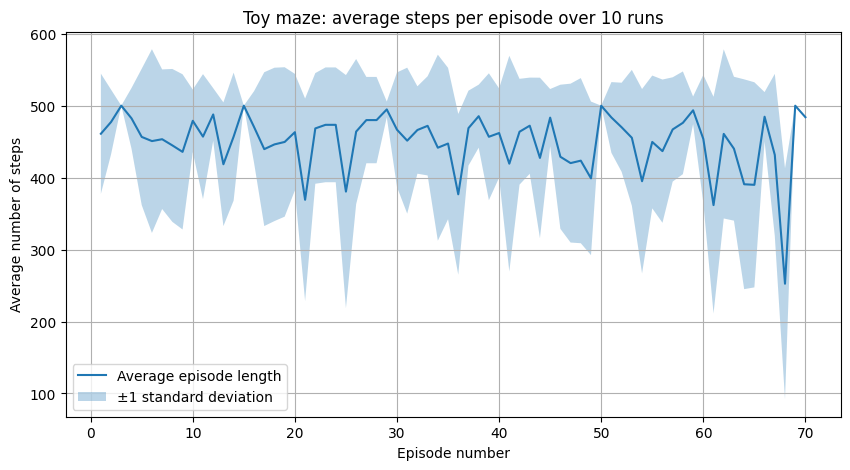

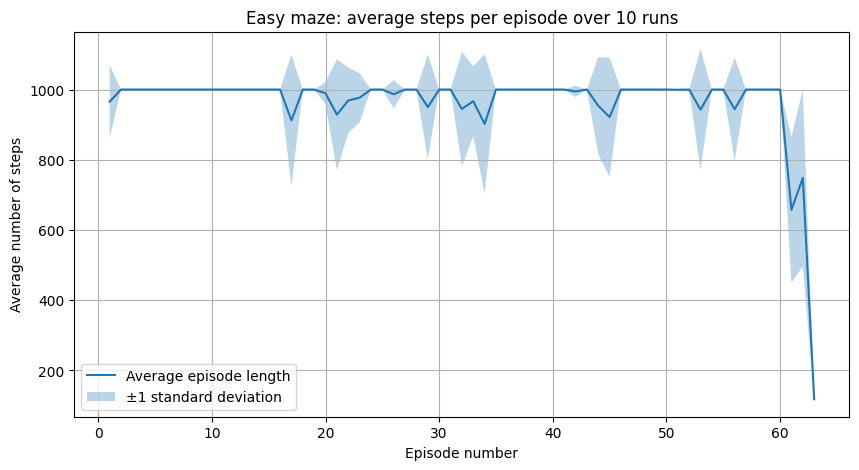

In [8]:
toy_mean, toy_std, toy_counts = plot_average_episode_lengths(
    toy_runs,
    "Toy maze: average steps per episode over 10 runs"
)

easy_mean, easy_std, easy_counts = plot_average_episode_lengths(
    easy_runs,
    "Easy maze: average steps per episode over 10 runs"
)

<div>

**Answer :**

We ran the agent 10 times on both the toy maze and the easy maze and recorded the number of steps taken in each episode. Since the learning step is still not implemented, the q-table never changes, so the agent should not improve over time.

The plots show the average number of steps per episode over the 10 runs. The shaded area represents one standard deviation, so it gives an indication of the uncertainty and variation between runs.

From both plots, we can see that the average number of steps does not show a clear downward trend. Instead, it stays roughly flat and fluctuates over time. This means that the agent is not learning a better policy. This is what we expected, because without updating the q-values, later episodes are not based on more knowledge than earlier episodes.

The easy maze generally has higher episode lengths than the toy maze, which also makes sense because it is larger and harder to navigate. In both cases, however, there is no consistent improvement across episodes.

There is a visible drop near the end of the curves. We do not interpret this as learning, because the last episode indices are based on fewer runs than the earlier ones. Not every run has the same number of episodes, so the final points are less stable and more sensitive to random variation.

Overall, the plots support the claim that the agent does not learn at this stage.


#### Question 5

In [9]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        
        alpha = self.params["lr"]
        gamma = self.params["gamma"]

        current_q = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            max_next_q = max([self.q_table.get_q(next_state, a) for a in possible_actions])
            target = reward + gamma * max_next_q

        new_q = current_q + alpha * (target - current_q)
        self.q_table.set_q(state, action, new_q)

In [10]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        
        alpha = self.params["lr"]
        gamma = self.params["gamma"]

        current_q = self.q_table.get_q(state, action)

        if done:
            target = reward
        else:
            next_q = self.q_table.get_q(next_state, next_action)
            target = reward + gamma * next_q

        new_q = current_q + alpha * (target - current_q)
        self.q_table.set_q(state, action, new_q)

<div>

**Answer :**

We implemented the learn() methods for both Q-learning and SARSA using the update equations from the assignment. In both methods, we use the learning rate (alpha = 0.7) and discount factor (gamma = 0.9). The parameter (varepsilon = 0.1) is used in the exploration strategy, not directly inside the learning update itself

For Q-learning, we update the q-value of the current state-action pair by using the reward plus the discounted value of the best possible next action. So even if the agent does not actually choose the best next action, Q-learning still learns toward that greedy target. Because of this, Q-learning is called an off-policy method

For SARSA, we also update the q-value of the current state-action pair, but now we use the reward plus the discounted value of the actual next action selected by the policy. This means the update depends on the behaviour of the current exploration strategy. Because of that, SARSA is and on-policy method

In both implementations, if the next state is terminal, we do not add a future q-value term anymore. In that case, the update target is just the immediate reward. This is necessary because once the terminal state is reached, the episode ends and there is no next action value to propagate

The main difference between the two methods is therefore in the target they use. Q-learning looks at the maximum q-value in the next state, while SARSA looks at the q-value of the next action that was really chosen. This usually makes Q-learning more optimistic and greedy, while SARSA tends to be more conservative because it learns according to the current policy, including exploration

#### Question 6

In [17]:
def run_qlearning(maze_path, total_step_limit, max_steps_per_episode=500, eps=0.1):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [18]:
def run_sarsa(maze_path, total_step_limit, max_steps_per_episode=500, eps=0.1):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = SARSA(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        state = agent.get_state(maze)
        action = exploration_strategy.e_greedy(agent, maze, eps=eps)

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            next_action = None
            if not done:
                next_action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            learner.learn(state, action, next_state, next_action, reward, done)

            state = next_state
            action = next_action

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [19]:
def plot_average_episode_lengths(all_runs, title):
    max_len = max(len(run) for run in all_runs)

    data = np.full((len(all_runs), max_len), np.nan)

    for i, run in enumerate(all_runs):
        data[i, :len(run)] = run

    mean_vals = np.nanmean(data, axis=0)
    std_vals = np.nanstd(data, axis=0)

    x = np.arange(1, max_len + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(x, mean_vals, label="Average episode length")
    plt.fill_between(
        x,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.3,
        label="±1 standard deviation"
    )
    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return mean_vals, std_vals

In [22]:
n_runs = 10

q_toy_runs = []
q_easy_runs = []
sarsa_toy_runs = []
sarsa_easy_runs = []

for i in range(n_runs):
    q_toy_runs.append(
        run_qlearning("../data/toy_maze.txt", total_step_limit=30000, max_steps_per_episode=500, eps=0.1)
    )
    print(f"Q-learning toy run {i+1} done")

for i in range(n_runs):
    q_easy_runs.append(
        run_qlearning("../data/easy_maze.txt", total_step_limit=300000, max_steps_per_episode=2000, eps=0.1)    
    )
    print(f"Q-learning easy run {i+1} done")

for i in range(n_runs):
    sarsa_toy_runs.append(
        run_sarsa("../data/toy_maze.txt", total_step_limit=30000, max_steps_per_episode=500, eps=0.1)
    )
    print(f"SARSA toy run {i+1} done")

for i in range(n_runs):
    sarsa_easy_runs.append(
        run_sarsa("../data/easy_maze.txt", total_step_limit=300000, max_steps_per_episode=2000, eps=0.1)
    )
    print(f"SARSA easy run {i+1} done")

Q-learning toy run 1 done
Q-learning toy run 2 done
Q-learning toy run 3 done
Q-learning toy run 4 done
Q-learning toy run 5 done
Q-learning toy run 6 done
Q-learning toy run 7 done
Q-learning toy run 8 done
Q-learning toy run 9 done
Q-learning toy run 10 done
Q-learning easy run 1 done
Q-learning easy run 2 done
Q-learning easy run 3 done
Q-learning easy run 4 done
Q-learning easy run 5 done
Q-learning easy run 6 done
Q-learning easy run 7 done
Q-learning easy run 8 done
Q-learning easy run 9 done
Q-learning easy run 10 done
SARSA toy run 1 done
SARSA toy run 2 done
SARSA toy run 3 done
SARSA toy run 4 done
SARSA toy run 5 done
SARSA toy run 6 done
SARSA toy run 7 done
SARSA toy run 8 done
SARSA toy run 9 done
SARSA toy run 10 done
SARSA easy run 1 done
SARSA easy run 2 done
SARSA easy run 3 done
SARSA easy run 4 done
SARSA easy run 5 done
SARSA easy run 6 done
SARSA easy run 7 done
SARSA easy run 8 done
SARSA easy run 9 done
SARSA easy run 10 done


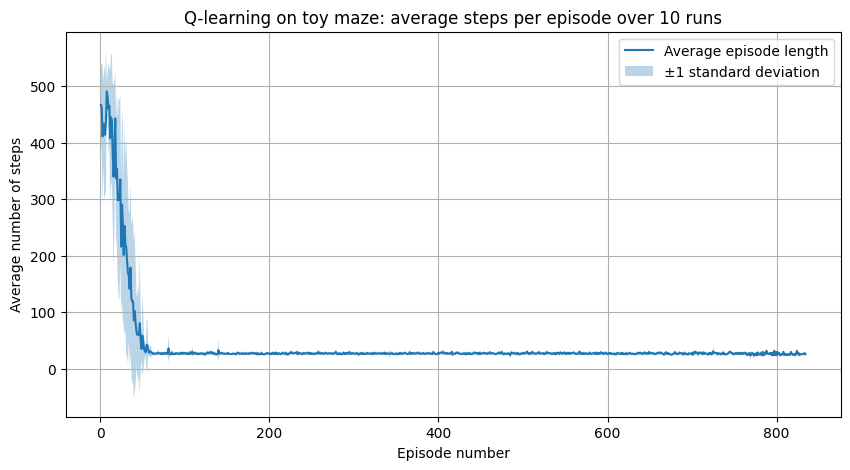

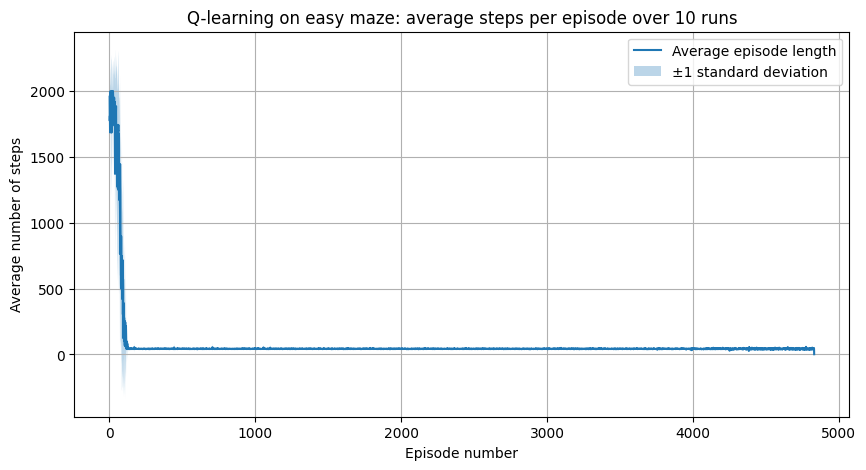

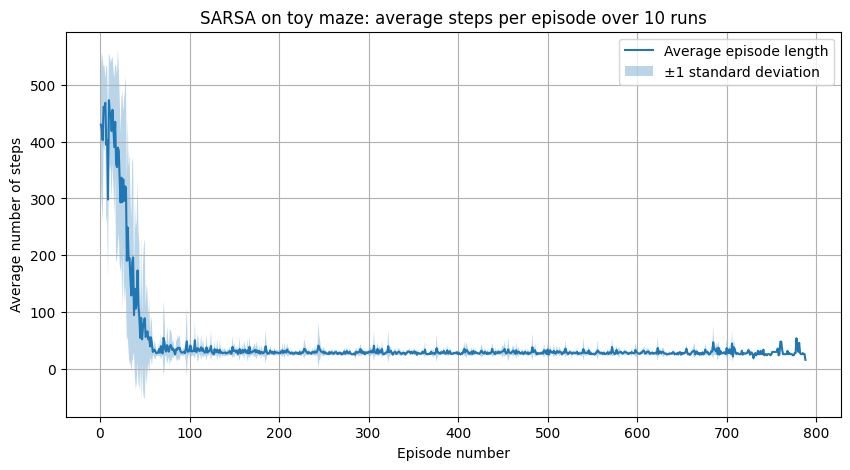

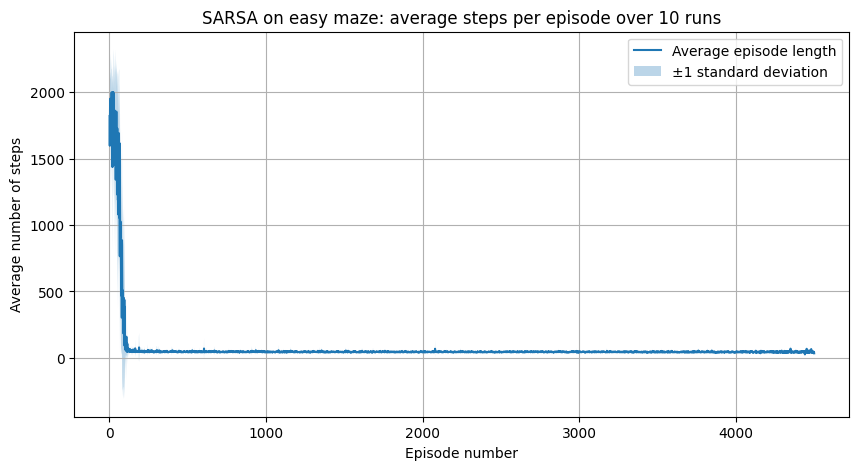

(array([1821.2, 1597. , 1786. , ...,   42. ,   44. ,   34. ], shape=(4502,)),
 array([378.30273591, 536.60059635, 328.04024143, ...,   0.        ,
          0.        ,   0.        ], shape=(4502,)))

In [23]:
plot_average_episode_lengths(q_toy_runs, "Q-learning on toy maze: average steps per episode over 10 runs")
plot_average_episode_lengths(q_easy_runs, "Q-learning on easy maze: average steps per episode over 10 runs")
plot_average_episode_lengths(sarsa_toy_runs, "SARSA on toy maze: average steps per episode over 10 runs")
plot_average_episode_lengths(sarsa_easy_runs, "SARSA on easy maze: average steps per episode over 10 runs")

<div>

**Answer :**

For this question, we ran both Q-learning and SARSA 10 times on both the toy maze and the easy maze. For each run, we recorded the number of steps taken in every episode and then plotted the average episode length over the 10 runs. We also included one standard deviation as an indication of uncertainty.

The plots clearly show that the agent does learn. In all four cases, the average number of steps per episode is high at the start and then decreases strongly over time. This means that in later episodes the agent is able to reach the goal in fewer steps than in earlier episodes. This is evidence that the q-values are being updated in a useful way and that the agent is learning a better policy for navigating through the maze.

The uncertainty is also larger in the beginning and becomes much smaller later on. This makes sense, because in the first episodes the agent still explores a lot and behaves less consistently. Once it has learned better state-action values, its behaviour becomes more stable.

For the toy maze, both algorithms learn relatively quickly and stabilize at low episode lengths. For the easy maze, learning takes longer, but the same overall pattern is visible: the average episode length eventually decreases a lot and then remains low. This is expected because the easy maze is larger and requires more exploration before the reward signal can propagate through the q-table.

Comparing the two methods, both Q-learning and SARSA are able to learn the environment. Q-learning appears slightly more aggressive, while SARSA is a bit more conservative, but in both cases the plots show a clear improvement over time.

Overall, these plots show that once the learning updates are implemented, the agent really does learn the environment, because later episodes require far fewer steps than the first episodes.


#### Question 7

<div>

<div>

**Answer :**

Yes, there are some differences between the robots trained with Q-learning and SARSA, although in our experiments both methods were able to learn successfully.

From the plots, both algorithms show the same general pattern: the average number of steps per episode decreases strongly over time, which means both agents improve. However, Q-learning seems a bit more aggressive, because it tends to reach low episode lengths slightly more directly. SARSA also learns well, but its curve looks a bit more cautious and sometimes slightly noisier before stabilizing.

The reason for this difference comes from the update equations. In **Q-learning**, the update uses the value of the **best possible next action**: $Q(s,a) \leftarrow Q(s,a) + \alpha \bigl(r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr)$. So even if the agent actually follows an exploratory action, the update still assumes the best next action will be taken. Because of this, Q-learning is called **off-policy** and usually learns more optimistically.

In **SARSA**, the update uses the value of the **next action that was actually chosen**: $Q(s,a) \leftarrow Q(s,a) + \alpha \bigl(r + \gamma Q(s',a') - Q(s,a)\bigr)$. Since the next action $a'$ is selected by the current policy, SARSA learns according to the real behaviour of the agent, including exploration. This makes it **on-policy** and usually a bit more conservative.

So the main difference is that Q-learning learns toward the greedy target, while SARSA learns toward the action that is really taken. That is why Q-learning often appears slightly faster or more aggressive, while SARSA can be a bit more careful. In our plots, this difference is visible, but both methods still clearly learn the maze.
</div>

### 2.2 Optimization
#### Question 8

In [24]:
def run_qlearning_with_epsilon(maze_path, total_step_limit, eps, max_steps_per_episode=500):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [25]:
def plot_multiple_epsilons(epsilon_runs_dict, title):
    plt.figure(figsize=(11, 6))

    for eps, all_runs in epsilon_runs_dict.items():
        max_len = max(len(run) for run in all_runs)
        data = np.full((len(all_runs), max_len), np.nan)

        for i, run in enumerate(all_runs):
            data[i, :len(run)] = run

        mean_vals = np.nanmean(data, axis=0)
        x = np.arange(1, max_len + 1)

        plt.plot(x, mean_vals, label=f"eps = {eps}")

    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [26]:
eps_values = [0.0, 0.05, 0.1, 0.3, 0.7]
n_runs = 10

toy_eps_runs = {}

for eps in eps_values:
    toy_eps_runs[eps] = []
    for i in range(n_runs):
        run = run_qlearning_with_epsilon(
            maze_path="../data/toy_maze.txt",
            total_step_limit=30000,
            eps=eps,
            max_steps_per_episode=500
        )
        toy_eps_runs[eps].append(run)
    print(f"Finished toy maze for eps = {eps}")

Finished toy maze for eps = 0.0
Finished toy maze for eps = 0.05
Finished toy maze for eps = 0.1
Finished toy maze for eps = 0.3
Finished toy maze for eps = 0.7


In [27]:
easy_eps_runs = {}

for eps in eps_values:
    easy_eps_runs[eps] = []
    for i in range(n_runs):
        run = run_qlearning_with_epsilon(
            maze_path="../data/easy_maze.txt",
            total_step_limit=300000,
            eps=eps,
            max_steps_per_episode=2000
        )
        easy_eps_runs[eps].append(run)
    print(f"Finished easy maze for eps = {eps}")

Finished easy maze for eps = 0.0
Finished easy maze for eps = 0.05
Finished easy maze for eps = 0.1
Finished easy maze for eps = 0.3
Finished easy maze for eps = 0.7


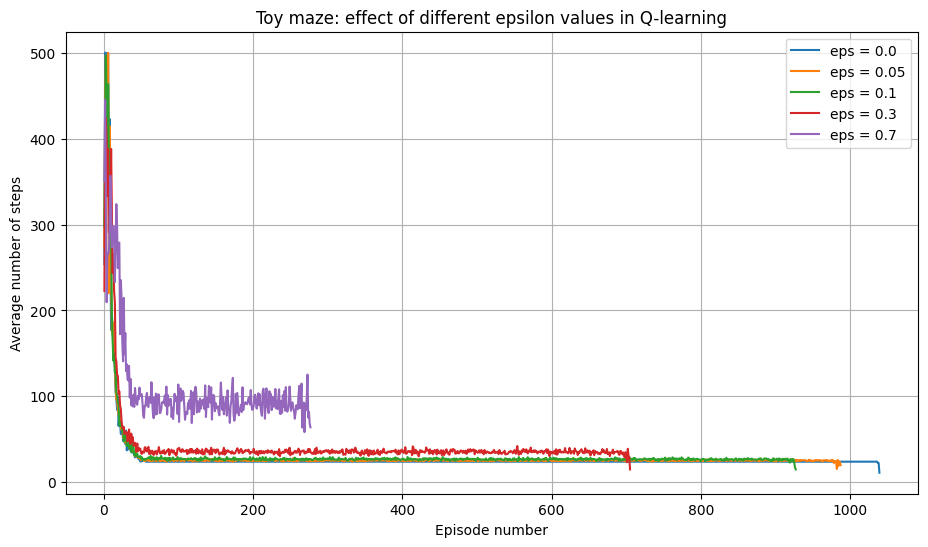

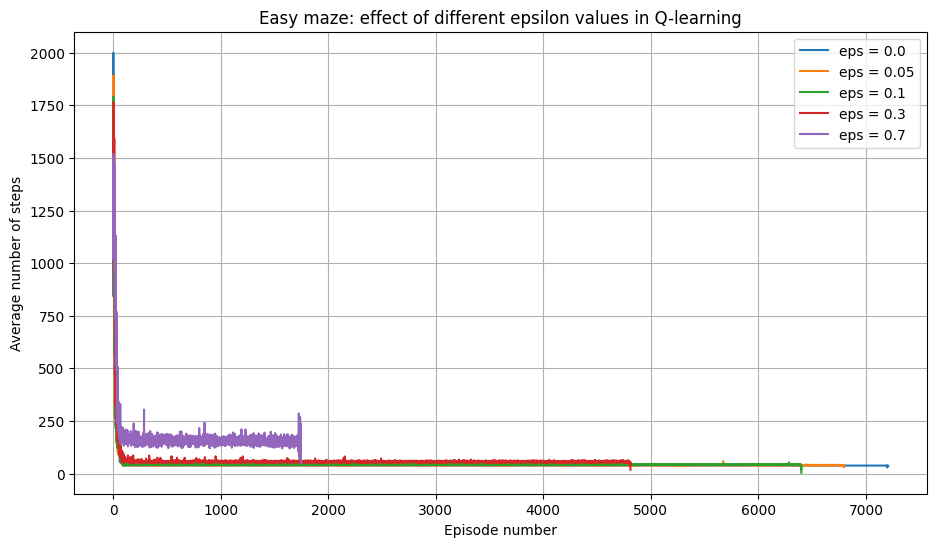

In [28]:
plot_multiple_epsilons(toy_eps_runs, "Toy maze: effect of different epsilon values in Q-learning")
plot_multiple_epsilons(easy_eps_runs, "Easy maze: effect of different epsilon values in Q-learning")

<div>

**Answer :**

We tested the $\varepsilon$-greedy strategy with five different values of $\varepsilon$: $0.0$, $0.05$, $0.1$, $0.3$, and $0.7$. For each value, we ran Q-learning 10 times and plotted the average number of steps per episode for both the toy maze and the easy maze.

From the plots, we can clearly see that the value of $\varepsilon$ affects the behaviour of the agent. All curves show learning, because the average number of steps decreases strongly at the beginning. However, the final performance depends on how much exploration is used.

For small values such as $\varepsilon = 0.0$ and $\varepsilon = 0.05$, the final episode lengths are lower. This means the agent behaves more greedily and is able to exploit the learned q-values better. The value $\varepsilon = 0.1$ also performs well and gives a good balance between exploration and exploitation.

For larger values such as $\varepsilon = 0.3$ and especially $\varepsilon = 0.7$, the final episode lengths are higher. This means the agent keeps taking too many random actions, even after it has already learned useful q-values. As a result, it reaches the goal less efficiently.

This happens because in $\varepsilon$-greedy exploration the agent chooses a random valid action with probability $\varepsilon$ and otherwise chooses the action with the highest q-value. So if $\varepsilon$ is too small, there is a risk of not exploring enough. But if $\varepsilon$ is too large, the agent keeps behaving too randomly and cannot fully benefit from what it has learned.

In our experiments, moderate or small values of $\varepsilon$ worked best. The effect is especially clear in the easy maze, where a large value like $\varepsilon = 0.7$ leads to much worse performance than the smaller values.

#### Question 9

<div>

**Answer :**

The main trade-off between high and low values of $\varepsilon$ is the balance between **exploration** and **exploitation**.

A **high** value of $\varepsilon$ means that the agent chooses random actions more often. The advantage is that the agent explores more of the environment and is less likely to miss potentially good paths. This is especially useful in the beginning, when the q-values are still unreliable. The disadvantage is that the agent keeps behaving quite randomly, so even later in training it may still take many unnecessary steps and perform worse on average.

A **low** value of $\varepsilon$ means that the agent chooses the greedy action more often. The advantage is that the agent can exploit what it has already learned and usually reaches the goal more efficiently. The disadvantage is that it may explore too little and get stuck with a suboptimal policy if it has not yet discovered better actions.

So, a high $\varepsilon$ helps the agent discover more, but can hurt final performance because of too much randomness. A low $\varepsilon$ improves efficiency once good q-values are known, but can hurt learning if the agent stops exploring too early. The best choice is usually a balance between the two.

#### Question 10

In [29]:
def run_qlearning_with_temperature(maze_path, total_step_limit, temperature, max_steps_per_episode=500):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.boltzmann(agent, maze, temperature=temperature)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [30]:
def plot_multiple_temperatures(temp_runs_dict, title):
    plt.figure(figsize=(11, 6))

    for temp, all_runs in temp_runs_dict.items():
        max_len = max(len(run) for run in all_runs)
        data = np.full((len(all_runs), max_len), np.nan)

        for i, run in enumerate(all_runs):
            data[i, :len(run)] = run

        mean_vals = np.nanmean(data, axis=0)
        x = np.arange(1, max_len + 1)

        plt.plot(x, mean_vals, label=f"T = {temp}")

    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [33]:
T_values = [0.01, 0.1, 0.5, 1.0, 5.0]
n_runs = 10

toy_T_runs = {}
easy_T_runs = {}

for T in T_values:
    toy_T_runs[T] = []
    for i in range(n_runs):
        run = run_qlearning_with_temperature(
            maze_path="../data/toy_maze.txt",
            total_step_limit=30000,
            temperature=T,
            max_steps_per_episode=500
        )
        toy_T_runs[T].append(run)
    print(f"Finished toy maze for T = {T}")

for T in T_values:
    easy_T_runs[T] = []
    for i in range(n_runs):
        run = run_qlearning_with_temperature(
            maze_path="../data/easy_maze.txt",
            total_step_limit=100000,
            temperature=T,
            max_steps_per_episode=1500
        )
        easy_T_runs[T].append(run)
    print(f"Finished easy maze for T = {T}")

Finished toy maze for T = 0.01
Finished toy maze for T = 0.1
Finished toy maze for T = 0.5
Finished toy maze for T = 1.0
Finished toy maze for T = 5.0
Finished easy maze for T = 0.01
Finished easy maze for T = 0.1
Finished easy maze for T = 0.5
Finished easy maze for T = 1.0
Finished easy maze for T = 5.0


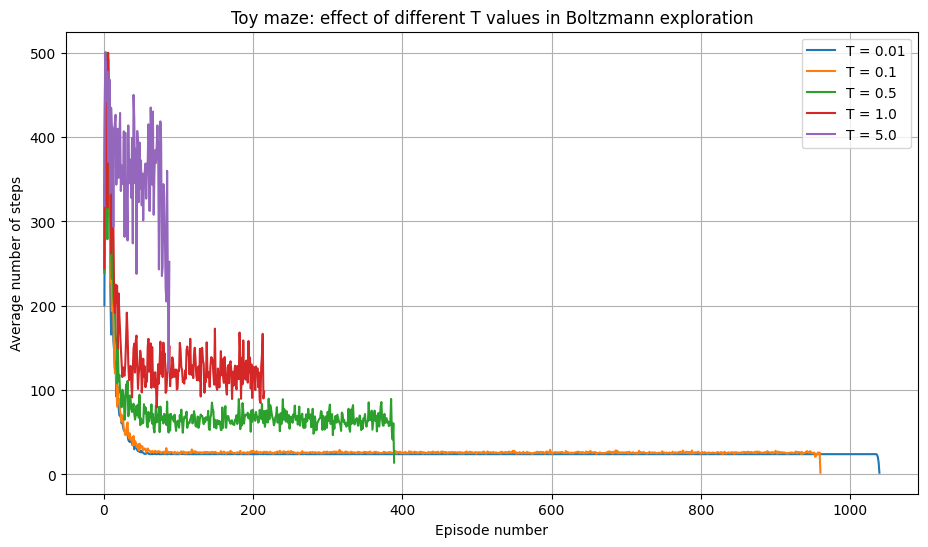

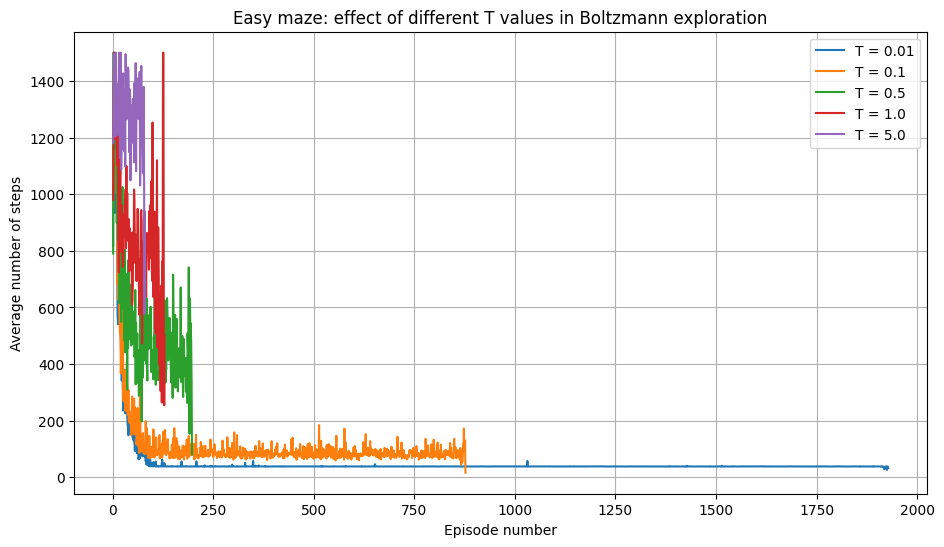

In [35]:
plot_multiple_temperatures(toy_T_runs, "Toy maze: effect of different T values in Boltzmann exploration")
plot_multiple_temperatures(easy_T_runs, "Easy maze: effect of different T values in Boltzmann exploration")

<div>

**Answer :**

We tested the Boltzmann exploration strategy with five different values of the temperature parameter $T$: $0.01$, $0.1$, $0.5$, $1.0$, and $5.0$. For each value, we ran Q-learning 10 times and plotted the average number of steps per episode for both the toy maze and the easy maze.

From the plots, we can see that the value of $T$ has a strong impact on the agent. Small values such as $T = 0.01$ and $T = 0.1$ perform best. In these cases, the average number of steps quickly decreases and stabilizes at a low value. This means that the agent is able to exploit the learned q-values effectively and follow a good route.

For larger values such as $T = 0.5$, $T = 1.0$, and especially $T = 5.0$, the performance is worse. The average number of steps stays much higher, and the learning process is more noisy. This indicates that the agent keeps exploring too much and does not exploit its learned knowledge efficiently.

The trade-off is that a high value of $T$ gives more exploration, because the action probabilities become more uniform. This can be useful in the beginning, when the agent still knows little about the environment. However, if $T$ is too high, the agent continues to behave too randomly, which hurts final performance. A low value of $T$ makes the policy more focused on the actions with the highest q-values, which improves efficiency once the agent has learned useful values. The downside is that if $T$ is too low, the agent may explore too little.

In our experiments, low values of $T$ worked best, while very large values led to too much randomness. So the best trade-off seems to be a low or moderate value of $T$, rather than a very high one.

#### Question 11

<div>

**Answer :**

Using the earlier experiments, we can compare the three exploration strategies: **random exploration**, **$\varepsilon$-greedy exploration**, and **Boltzmann exploration**.

The **random strategy** performs worst overall. It does guarantee exploration, but it ignores the q-values completely. Because of that, even after the agent has learned useful information about the maze, it still keeps choosing actions uniformly at random. This prevents it from exploiting its learned policy efficiently, so the average number of steps stays relatively high.

Both **$\varepsilon$-greedy** and **Boltzmann** perform much better than pure random exploration, because they both make use of the q-values. However, based on our tuning experiments, **$\varepsilon$-greedy performed best overall**. With a well-chosen value such as a small or moderate $\varepsilon$, the agent still explores enough to discover useful paths, but most of the time it exploits the currently best action. This gives a strong balance between exploration and exploitation and leads to low final episode lengths.

**Boltzmann exploration** also works well, but it is more sensitive to the choice of the temperature parameter $T$. If $T$ is too high, the policy becomes too random and performance becomes much worse. If $T$ is too low, the policy becomes almost greedy. In our experiments, low values of $T$ worked well, but overall the strategy seemed less robust than $\varepsilon$-greedy because performance changed more strongly when the parameter was not chosen well.

So, the best strategy in our experiments was **$\varepsilon$-greedy exploration**. The main reason is that it is simple, stable, and gives a very direct way to control the amount of exploration. It preserves enough randomness to discover good actions, while still exploiting the learned q-values most of the time. Random exploration does not exploit at all, and Boltzmann exploration can work very well, but it is more sensitive to the temperature choice and therefore less consistent in practice.

#### Question 12

In [36]:
def run_qlearning_with_alpha(maze_path, total_step_limit, alpha, eps=0.1, max_steps_per_episode=500):
    maze = Maze(maze_path)
    maze.set_reward(x=maze.width - 1, y=maze.height - 1, reward=10)
    maze.set_terminal(x=maze.width - 1, y=maze.height - 1)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)

    params = {"lr": alpha, "gamma": 0.9}
    learner = QLearning(q_table, params)

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return episode_lengths

In [40]:
def plot_multiple_alphas(alpha_runs_dict, title, max_episode=None):
    plt.figure(figsize=(11, 6))

    for alpha, all_runs in alpha_runs_dict.items():
        max_len = max(len(run) for run in all_runs)
        data = np.full((len(all_runs), max_len), np.nan)

        for i, run in enumerate(all_runs):
            data[i, :len(run)] = run

        mean_vals = np.nanmean(data, axis=0)
        x = np.arange(1, max_len + 1)

        if max_episode is not None:
            x = x[:max_episode]
            mean_vals = mean_vals[:max_episode]

        plt.plot(x, mean_vals, label=f"$\\alpha = {alpha}$")

    plt.xlabel("Episode number")
    plt.ylabel("Average number of steps")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [41]:
alpha_values = [0.05, 0.1, 0.3, 0.7, 0.95]
n_runs = 10

toy_alpha_runs = {}
easy_alpha_runs = {}

for alpha in alpha_values:
    toy_alpha_runs[alpha] = []
    for i in range(n_runs):
        run = run_qlearning_with_alpha(
            maze_path="../data/toy_maze.txt",
            total_step_limit=30000,
            alpha=alpha,
            eps=0.1,
            max_steps_per_episode=500
        )
        toy_alpha_runs[alpha].append(run)
    print(f"Finished toy maze for alpha = {alpha}")

for alpha in alpha_values:
    easy_alpha_runs[alpha] = []
    for i in range(n_runs):
        run = run_qlearning_with_alpha(
            maze_path="../data/easy_maze.txt",
            total_step_limit=100000,
            alpha=alpha,
            eps=0.1,
            max_steps_per_episode=1500
        )
        easy_alpha_runs[alpha].append(run)
    print(f"Finished easy maze for alpha = {alpha}")

Finished toy maze for alpha = 0.05
Finished toy maze for alpha = 0.1
Finished toy maze for alpha = 0.3
Finished toy maze for alpha = 0.7
Finished toy maze for alpha = 0.95
Finished easy maze for alpha = 0.05
Finished easy maze for alpha = 0.1
Finished easy maze for alpha = 0.3
Finished easy maze for alpha = 0.7
Finished easy maze for alpha = 0.95


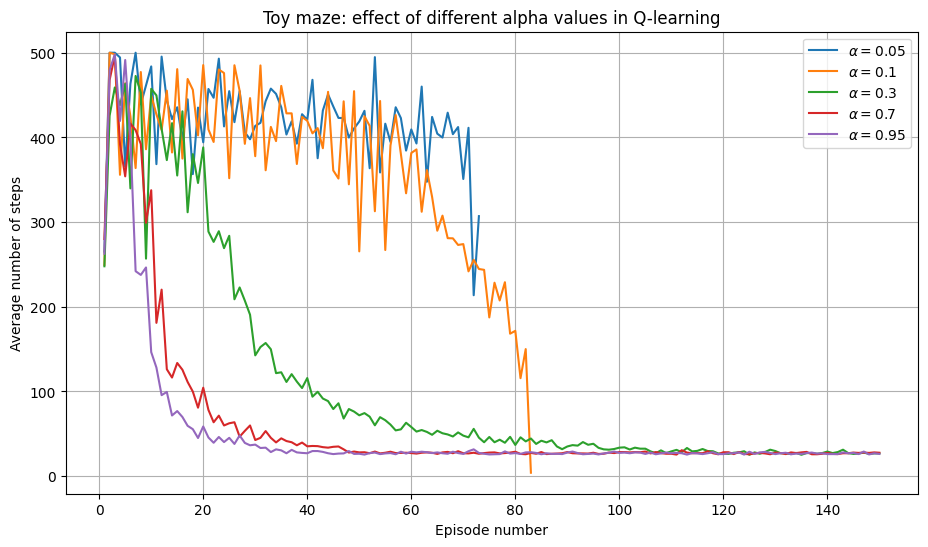

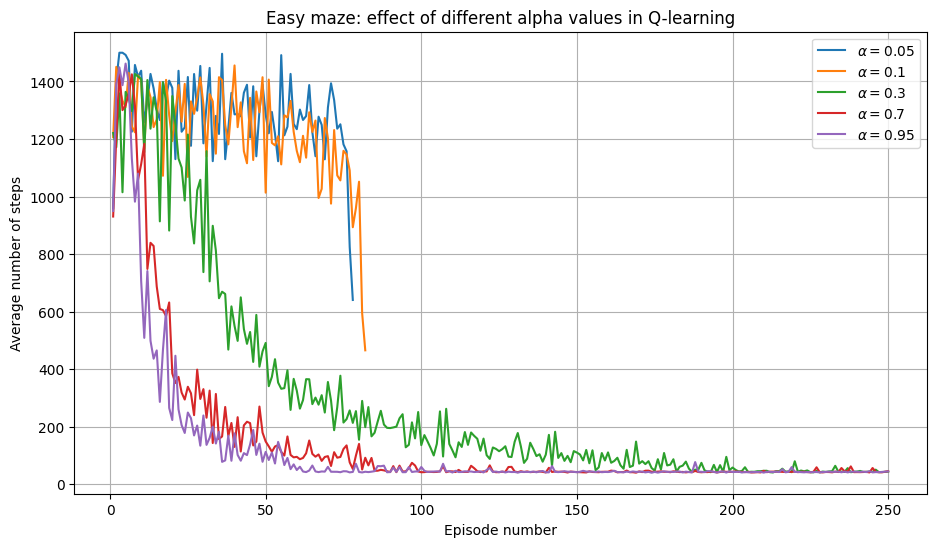

In [42]:
plot_multiple_alphas(toy_alpha_runs, "Toy maze: effect of different alpha values in Q-learning", max_episode=150)
plot_multiple_alphas(easy_alpha_runs, "Easy maze: effect of different alpha values in Q-learning", max_episode=250)

<div>

**Answer :**

We tested five different values of the learning rate $\alpha$: $0.05$, $0.1$, $0.3$, $0.7$, and $0.95$. For each value, we ran Q-learning 10 times and plotted the average number of steps per episode.

From the plots, we can clearly see that the learning rate has a strong effect on how fast the agent improves. Small values such as $\alpha = 0.05$ and $\alpha = 0.1$ lead to slow learning. In both mazes, these curves stay high for longer and only decrease after many more episodes. This means the q-values are updated only slowly.

Medium and larger values such as $\alpha = 0.3$, $\alpha = 0.7$, and $\alpha = 0.95$ lead to much faster improvement. Their curves drop much earlier, which shows that the agent learns good state-action values more quickly. In particular, $\alpha = 0.7$ and $\alpha = 0.95$ perform best in terms of learning speed.

At the same time, a very large learning rate can be slightly more aggressive. Since new experiences get a lot of weight, the q-values can change more strongly from one update to the next. This can make learning less stable, even if it is very fast. In our plots, $\alpha = 0.95$ learns very quickly, but values like $\alpha = 0.7$ seem to give a better balance between speed and stability.

This happens because $\alpha$ determines how much new information influences the q-value update. A small $\alpha$ means the agent changes its q-values only a little after each step, so learning is slow but smooth. A large $\alpha$ means the agent reacts much more strongly to recent rewards and transitions, so learning is faster, but it can also become noisier.

So the main effect of $\alpha$ is the trade-off between **learning speed** and **stability**. Low values are more stable but much slower, while high values learn faster but may be more sensitive to recent experiences. In our experiments, medium-to-high values such as $\alpha = 0.7$ gave the best overall behaviour.

### 2.3 Introducing More Rewards
#### Question 13

In [43]:
# Question 13: toy maze with a second reward at (9, 0)

def train_qlearning_two_rewards(total_step_limit=30000, alpha=0.7, gamma=0.9, eps=0.1, max_steps_per_episode=500):
    maze = Maze("../data/toy_maze.txt")

    # original target
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # second target
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0
    episode_lengths = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        episode_lengths.append(episode_steps)

    return maze, q_table, episode_lengths


def greedy_rollout_two_rewards(q_table, max_steps=100):
    maze = Maze("../data/toy_maze.txt")

    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), path


# run several times
results = []

for i in range(10):
    maze, q_table, episode_lengths = train_qlearning_two_rewards(
        total_step_limit=30000,
        alpha=0.7,
        gamma=0.9,
        eps=0.1,
        max_steps_per_episode=500
    )

    target_pos, target_reward, path = greedy_rollout_two_rewards(q_table)
    results.append((target_pos, target_reward, len(path) - 1))
    print(f"Run {i+1}: target = {target_pos}, reward = {target_reward}, path length = {len(path) - 1}")

Run 1: target = (9, 9), reward = 10, path length = 24
Run 2: target = (9, 9), reward = 10, path length = 24
Run 3: target = (9, 9), reward = 10, path length = 24
Run 4: target = (9, 9), reward = 10, path length = 24
Run 5: target = (9, 9), reward = 10, path length = 24
Run 6: target = (9, 9), reward = 10, path length = 24
Run 7: target = (9, 9), reward = 10, path length = 24
Run 8: target = (9, 9), reward = 10, path length = 24
Run 9: target = (9, 9), reward = 10, path length = 24
Run 10: target = (9, 9), reward = 10, path length = 24


Chosen target: (9, 9) reward: 10


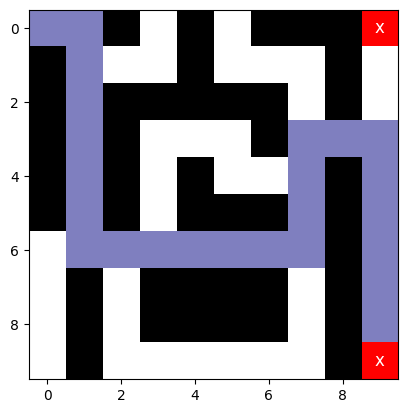

In [49]:
target_pos, target_reward, path = greedy_rollout_two_rewards(q_table)
print("Chosen target:", target_pos, "reward:", target_reward)
maze.visualize(path)

<div>

**Answer :**

After adding a second reward of $5$ at position $(9,0)$ and making it a second terminal state, the agent often learns to go to the top-right corner instead of the bottom-right corner, even though the reward there is smaller.

The main reason is that the reward of $5$ is much closer to the starting point than the reward of $10$. In Q-learning, the agent does not only care about the reward size itself, but about the **discounted return**. Because future rewards are multiplied by the discount factor $\gamma$, a reward that is further away becomes less valuable. So even though $10 > 5$, the reward of $5$ can still become more attractive if it can be reached in fewer steps.

So what we observe is that the robot may prefer the smaller but closer reward over the larger but more distant reward. When we run the program several times, the agent often converges to the top-right target, because it is easier to reach and therefore gives a higher effective return after discounting.

In other words, the agent is not optimizing for the largest immediate reward, but for the largest **discounted cumulative return**. That is why the closer reward of $5$ can dominate the further reward of $10$.

#### Question 14

In [50]:
# Question 14: compare Q-learning and SARSA on the two-reward toy maze

def make_two_reward_toy_maze():
    maze = Maze("../data/toy_maze.txt")

    # reward 10 at bottom-right
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # reward 5 at top-right
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    return maze


def train_qlearning_two_rewards(total_step_limit=30000, alpha=0.7, gamma=0.9, eps=0.1, max_steps_per_episode=500):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)
            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

    return q_table


def train_sarsa_two_rewards(total_step_limit=30000, alpha=0.7, gamma=0.9, eps=0.1, max_steps_per_episode=500):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = SARSA(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        state = agent.get_state(maze)
        action = exploration_strategy.e_greedy(agent, maze, eps=eps)

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            next_action = None
            if not done:
                next_action = exploration_strategy.e_greedy(agent, maze, eps=eps)

            learner.learn(state, action, next_state, next_action, reward, done)

            state = next_state
            action = next_action

            episode_steps += 1
            total_steps += 1

    return q_table


def greedy_rollout_on_two_reward_maze(q_table, max_steps=100):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), path


# compare both algorithms several times
qlearning_results = []
sarsa_results = []

for i in range(10):
    q_qtable = train_qlearning_two_rewards()
    q_target, q_reward, q_path = greedy_rollout_on_two_reward_maze(q_qtable)
    qlearning_results.append((q_target, q_reward, len(q_path) - 1))

    s_qtable = train_sarsa_two_rewards()
    s_target, s_reward, s_path = greedy_rollout_on_two_reward_maze(s_qtable)
    sarsa_results.append((s_target, s_reward, len(s_path) - 1))

    print(f"Run {i+1}")
    print(f"  Q-learning -> target = {q_target}, reward = {q_reward}, path length = {len(q_path) - 1}")
    print(f"  SARSA      -> target = {s_target}, reward = {s_reward}, path length = {len(s_path) - 1}")

print("\nQ-learning results:", qlearning_results)
print("SARSA results:", sarsa_results)

Run 1
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 2
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 3
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 4
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 5
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 6
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 9), reward = 10, path length = 24
Run 7
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA      -> target = (9, 0), reward = 5, path length = 21
Run 8
  Q-learning -> target = (9, 9), reward = 10, path length = 24
  SARSA 

<div>

**Answer :**

Switching from Q-learning to SARSA does not really solve the problem. In our experiment, Q-learning always converged to the reward of $10$ at $(9,9)$, while SARSA usually also chose that target, but in one run it converged to the closer reward of $5$ at $(9,0)$. So SARSA can behave a bit differently, but it does not fundamentally remove the issue.

The reason is that both algorithms still optimize **discounted return**. If a smaller reward can be reached much faster, it can still become attractive because future rewards are discounted by $\gamma$. So the closer reward of $5$ may still compete with the further reward of $10$.

The difference between the methods comes from their update equations. Q-learning uses
$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl(r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr)$,
so it is **off-policy** and updates toward the best possible next action. SARSA uses
$Q(s,a) \leftarrow Q(s,a) + \alpha \bigl(r + \gamma Q(s',a') - Q(s,a)\bigr)$,
so it is **on-policy** and updates according to the next action that was actually chosen by the current policy.

Because SARSA includes the effect of exploration in its updates, it is usually a bit more conservative and can sometimes prefer a safer or closer option. That explains why in our runs SARSA once converged to the smaller reward of $5$, while Q-learning consistently preferred the reward of $10$.

So SARSA does not really fix the problem. It may change the behaviour slightly, but the main issue remains the same: the agent is optimizing discounted future reward, not simply the largest raw reward.

#### Question 15

Run 1: final greedy target = (9, 9), reward = 10
Run 2: final greedy target = (9, 9), reward = 10
Run 3: final greedy target = (9, 9), reward = 10
Run 4: final greedy target = (9, 9), reward = 10
Run 5: final greedy target = (9, 9), reward = 10
Run 6: final greedy target = (9, 9), reward = 10
Run 7: final greedy target = (9, 9), reward = 10
Run 8: final greedy target = (9, 9), reward = 10
Run 9: final greedy target = (9, 9), reward = 10
Run 10: final greedy target = (9, 9), reward = 10


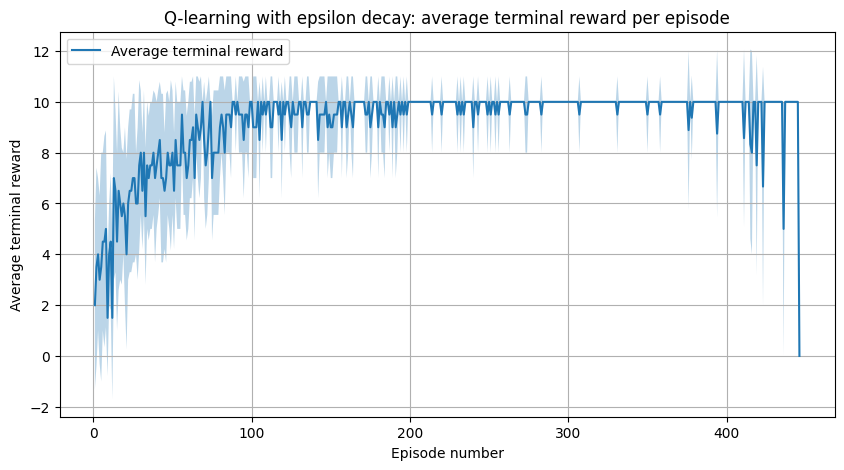

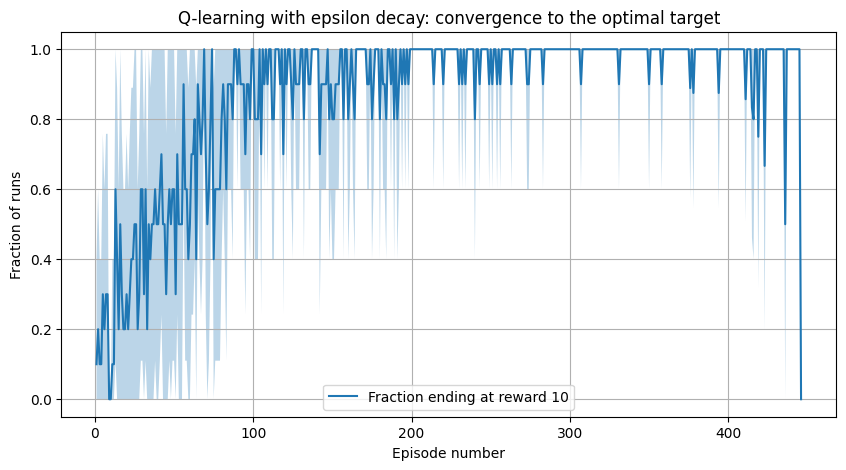

Final greedy targets across runs: [((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10), ((9, 9), 10)]


In [52]:
def make_two_reward_toy_maze():
    maze = Maze("../data/toy_maze.txt")

    # original larger reward
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # closer smaller reward
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    return maze


def run_qlearning_two_rewards_with_decay(
    total_step_limit=30000,
    alpha=0.7,
    gamma=0.9,
    eps_start=1.0,
    eps_decay=0.995,
    eps_min=0.01,
    max_steps_per_episode=500
):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0
    epsilon = eps_start

    episode_lengths = []
    terminal_rewards = []
    terminal_targets = []

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0
        final_reward = 0
        final_target = None

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=epsilon)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

            if done:
                final_reward = reward
                final_target = (next_state.x, next_state.y)

        episode_lengths.append(episode_steps)
        terminal_rewards.append(final_reward)
        terminal_targets.append(final_target)

        # epsilon decay after each episode
        epsilon = max(eps_min, epsilon * eps_decay)

    return q_table, episode_lengths, terminal_rewards, terminal_targets


def greedy_rollout_two_rewards(q_table, max_steps=100):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), path


def pad_and_average(runs):
    max_len = max(len(run) for run in runs)
    data = np.full((len(runs), max_len), np.nan)

    for i, run in enumerate(runs):
        data[i, :len(run)] = run

    mean_vals = np.nanmean(data, axis=0)
    std_vals = np.nanstd(data, axis=0)
    return mean_vals, std_vals


# run several times
n_runs = 10
all_reward_runs = []
all_optimal_indicator_runs = []
final_targets = []

for i in range(n_runs):
    q_table, episode_lengths, terminal_rewards, terminal_targets = run_qlearning_two_rewards_with_decay(
        total_step_limit=30000,
        alpha=0.7,
        gamma=0.9,
        eps_start=1.0,
        eps_decay=0.995,
        eps_min=0.01,
        max_steps_per_episode=500
    )

    all_reward_runs.append(terminal_rewards)

    # 1 if episode ended at the optimal reward (9,9), else 0
    optimal_indicator = [1 if t == (9, 9) else 0 for t in terminal_targets]
    all_optimal_indicator_runs.append(optimal_indicator)

    target_pos, target_reward, path = greedy_rollout_two_rewards(q_table)
    final_targets.append((target_pos, target_reward))
    print(f"Run {i+1}: final greedy target = {target_pos}, reward = {target_reward}")

# average reward per episode
mean_rewards, std_rewards = pad_and_average(all_reward_runs)
x1 = np.arange(1, len(mean_rewards) + 1)

plt.figure(figsize=(10, 5))
plt.plot(x1, mean_rewards, label="Average terminal reward")
plt.fill_between(x1, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3)
plt.xlabel("Episode number")
plt.ylabel("Average terminal reward")
plt.title("Q-learning with epsilon decay: average terminal reward per episode")
plt.grid(True)
plt.legend()
plt.show()

# fraction of runs choosing the optimal target (9,9)
mean_optimal, std_optimal = pad_and_average(all_optimal_indicator_runs)
x2 = np.arange(1, len(mean_optimal) + 1)

plt.figure(figsize=(10, 5))
plt.plot(x2, mean_optimal, label="Fraction ending at reward 10")
plt.fill_between(
    x2,
    np.maximum(0, mean_optimal - std_optimal),
    np.minimum(1, mean_optimal + std_optimal),
    alpha=0.3
)
plt.xlabel("Episode number")
plt.ylabel("Fraction of runs")
plt.title("Q-learning with epsilon decay: convergence to the optimal target")
plt.grid(True)
plt.legend()
plt.show()

print("Final greedy targets across runs:", final_targets)

<div>

**Answer :**

To mitigate the previous problem, we changed the value of $\varepsilon$ over time instead of keeping it fixed. We used an **epsilon-decay** strategy: the agent starts with a high value of $\varepsilon$, so it explores a lot in the beginning, and then $\varepsilon$ is gradually reduced after each episode. This means that early on the agent is encouraged to discover both reward locations, while later it becomes more greedy and exploits the better long-term option.

This helps because with a fixed exploration rate, the agent can converge too early to the closer reward of $5$ at $(9,0)$. Even though that reward is smaller, it is easier to find, so the agent may keep exploiting it before it has properly explored the better reward of $10$ at $(9,9)$. By starting with more exploration and then slowly reducing it, the agent gets enough chance to discover both options and later commit to the optimal one.

The plots show that this works. The **average terminal reward** increases toward $10$, and the **fraction of runs ending at the optimal target** rises toward $1$. In addition, the final greedy evaluation confirms that all 10 runs converged to the reward of $10$ at $(9,9)$. This shows that the previous problem was successfully mitigated.

This idea is consistent with standard reinforcement learning practice: exploration should be higher in the beginning, when the agent still knows little about the environment, and lower later, when the agent should exploit what it has learned. In that way, epsilon decay helps prevent premature convergence to the suboptimal closer reward while still allowing strong exploitation in the final policy.

#### Question 16

gamma = 0.40 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.45 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.50 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.55 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21)]
fraction choosing smaller reward (9,0): 1.00

gamma = 0.60 -> [((9, 0), 5, 21), ((9, 0), 5, 21), ((9, 0), 5, 21), 

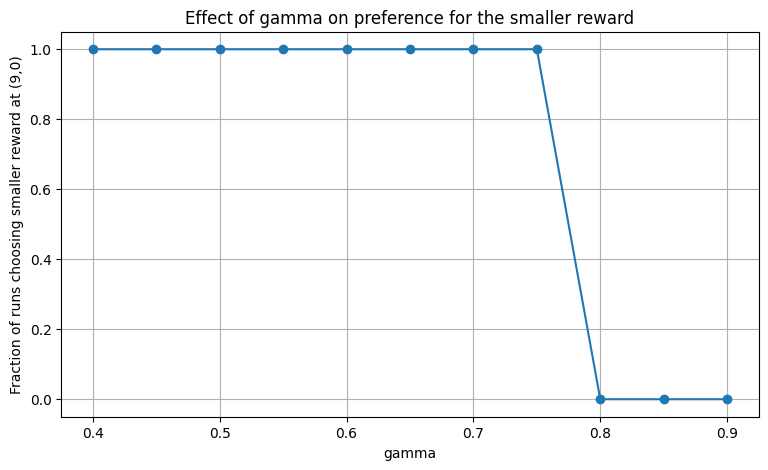

fine gamma = 0.760 -> fraction smaller reward = 1.00
fine gamma = 0.770 -> fraction smaller reward = 1.00
fine gamma = 0.780 -> fraction smaller reward = 1.00
fine gamma = 0.790 -> fraction smaller reward = 1.00
fine gamma = 0.795 -> fraction smaller reward = 0.00
fine gamma = 0.800 -> fraction smaller reward = 0.00


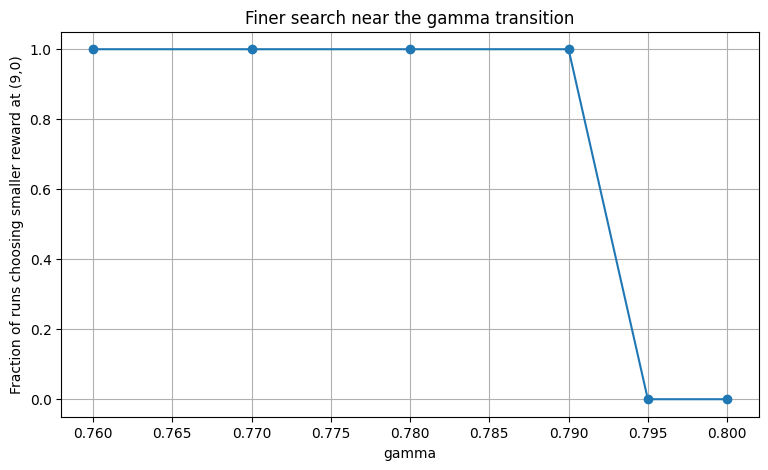

In [56]:
# ---------- same two-reward maze as before ----------
def make_two_reward_toy_maze():
    maze = Maze("../data/toy_maze.txt")

    # larger reward at bottom-right
    maze.set_reward(x=9, y=9, reward=10)
    maze.set_terminal(x=9, y=9)

    # smaller reward at top-right
    maze.set_reward(x=9, y=0, reward=5)
    maze.set_terminal(x=9, y=0)

    return maze


# ---------- Q-learning with epsilon decay ----------
def train_qlearning_two_rewards_with_decay_gamma(
    gamma,
    total_step_limit=30000,
    alpha=0.7,
    eps_start=1.0,
    eps_decay=0.995,
    eps_min=0.01,
    max_steps_per_episode=500
):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)

    states = maze.get_all_states()
    actions = [Action(i) for i in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions, initial_value=100)

    exploration_strategy = ExplorationStrategy(q_table)
    learner = QLearning(q_table, {"lr": alpha, "gamma": gamma})

    total_steps = 0
    epsilon = eps_start

    while total_steps < total_step_limit:
        agent.reset()
        done = False
        episode_steps = 0

        while not done and total_steps < total_step_limit and episode_steps < max_steps_per_episode:
            state = agent.get_state(maze)
            action = exploration_strategy.e_greedy(agent, maze, eps=epsilon)

            if action is None:
                break

            next_state, reward, done = agent.step(action, maze)

            possible_actions = agent.get_valid_actions(maze)
            learner.learn(possible_actions, state, action, next_state, reward, done)

            episode_steps += 1
            total_steps += 1

        epsilon = max(eps_min, epsilon * eps_decay)

    return q_table


# ---------- greedy rollout after training ----------
def greedy_rollout_two_rewards(q_table, max_steps=100):
    maze = make_two_reward_toy_maze()
    agent = Agent(start_x=0, start_y=0)
    path = [(agent.y, agent.x)]

    for _ in range(max_steps):
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if len(valid_actions) == 0:
            break

        q_values = [q_table.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)

        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        action = best_actions[np.random.choice(len(best_actions))]

        next_state, reward, done = agent.step(action, maze)
        path.append((agent.y, agent.x))

        if done:
            return (agent.x, agent.y), reward, len(path) - 1, path

    return (agent.x, agent.y), maze.get_reward(agent.x, agent.y), len(path) - 1, path


# ---------- experimental gamma sweep ----------
gamma_values = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
n_runs = 10

gamma_results = {}
fraction_small_reward = []

for gamma in gamma_values:
    results_for_gamma = []

    for i in range(n_runs):
        q_table = train_qlearning_two_rewards_with_decay_gamma(
            gamma=gamma,
            total_step_limit=30000,
            alpha=0.7,
            eps_start=1.0,
            eps_decay=0.995,
            eps_min=0.01,
            max_steps_per_episode=500
        )

        target_pos, target_reward, path_length, path = greedy_rollout_two_rewards(q_table)
        results_for_gamma.append((target_pos, target_reward, path_length))

    gamma_results[gamma] = results_for_gamma

    # count how often the smaller reward (9,0) is chosen
    small_count = sum(1 for target_pos, reward, _ in results_for_gamma if target_pos == (9, 0))
    fraction_small = small_count / n_runs
    fraction_small_reward.append(fraction_small)

    print(f"gamma = {gamma:.2f} -> {results_for_gamma}")
    print(f"fraction choosing smaller reward (9,0): {fraction_small:.2f}\n")


# ---------- plot ----------
plt.figure(figsize=(9, 5))
plt.plot(gamma_values, fraction_small_reward, marker="o")
plt.xlabel("gamma")
plt.ylabel("Fraction of runs choosing smaller reward at (9,0)")
plt.title("Effect of gamma on preference for the smaller reward")
plt.grid(True)
plt.show()


# ---------- optional finer sweep near transition ----------
fine_gamma_values = [0.76, 0.77, 0.78, 0.79, 0.795, 0.80]
fine_fraction_small = []

for gamma in fine_gamma_values:
    small_count = 0

    for i in range(n_runs):
        q_table = train_qlearning_two_rewards_with_decay_gamma(
            gamma=gamma,
            total_step_limit=30000,
            alpha=0.7,
            eps_start=1.0,
            eps_decay=0.995,
            eps_min=0.01,
            max_steps_per_episode=500
        )

        target_pos, target_reward, path_length, path = greedy_rollout_two_rewards(q_table)

        if target_pos == (9, 0):
            small_count += 1

    frac = small_count / n_runs
    fine_fraction_small.append(frac)
    print(f"fine gamma = {gamma:.3f} -> fraction smaller reward = {frac:.2f}")

plt.figure(figsize=(9, 5))
plt.plot(fine_gamma_values, fine_fraction_small, marker="o")
plt.xlabel("gamma")
plt.ylabel("Fraction of runs choosing smaller reward at (9,0)")
plt.title("Finer search near the gamma transition")
plt.grid(True)
plt.show()

<div>

**Answer :**

Using the epsilon-decay solution from Question 15, we experimentally searched for a value of $\gamma$ for which the agent prefers the smaller reward of $5$ at $(9,0)$ instead of the larger reward of $10$ at $(9,9)$.

From the coarse experiment, we found that the transition happens between $\gamma = 0.75$ and $\gamma = 0.80$. We then refined the search around that interval and found that the switch happens between $\gamma = 0.790$ and $\gamma = 0.795$. So experimentally, the critical value is approximately $\gamma \approx 0.794$.

We can confirm this value with a derivation. From the greedy rollouts, the path to the smaller reward has length $21$ steps, while the path to the larger reward has length $24$ steps. Since the reward is only obtained at the terminal state, the discounted returns are:

- smaller reward: $5\gamma^{20}$
- larger reward: $10\gamma^{23}$

The threshold is the value of $\gamma$ for which both discounted returns are equal:

$5\gamma^{20} = 10\gamma^{23}$

Dividing both sides by $5\gamma^{20}$ gives:

$1 = 2\gamma^3$

so

$\gamma^3 = \frac{1}{2}$

and therefore

$\gamma = \left(\frac{1}{2}\right)^{1/3} \approx 0.794$.

This matches the experimental results very well, because our finer search showed that the switch occurs between $0.790$ and $0.795$. Therefore, the critical value is approximately $\gamma \approx 0.794$.

So the conclusion is that if $\gamma$ is below this value, the smaller but closer reward is optimal under discounting, while if $\gamma$ is above this value, the larger but further reward becomes optimal.

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div>

Give at least one downside of an algorithm that is greedy with its action selection.

***ANSWER:***
There has to be a discussion between the importance of exploration vs exploitation in the context of Reinforcement Learning. An algorithm that is purely greedy with its action selection completely ignores the former and focuses on the latter. This would imply mathematically choosing the action that maximizes the highest option out of all currently known Q-values. Due to the fact that it never bothers to check unvisited or currently "lower value" states, it risks getting stuck in a **local optimum**. For *example*, a grocery shop agent might get stuck in an unnecessarily long path that eventually reaches the target inefficiently because the unknown aisle currently had a Q-value of 0.

#### Question 18

<div>

When and why can reward functions cause problems in the society? Think in terms of
agents “understanding” the point of their reward functions.

***ANSWER:*** According to **Felix Hofstätter** in ***"How learning reward functions can go wrong"***, reward functions can be problematic through ***Specification Gaming***. Such a phenomenon appears when the objective's definition may not accurately capture the human's intention. To give a real-world example of how there might be unwanted behaviours, researchers at OpenAI once trained an RL agent on the game CoastRunners, which is about a motorboat race. In a textbook example of misspecified reward, the game does not reward the agent for its progression along the track, but for hitting targets laid out along the track. This loophole was exploited by the agent who found a strategy for hitting targets without finishing the race. At a societal level, a social media algorithm might act similarly by maximizing clicks and completely ignoring the true human intent of fostering a healthy community.

#### Question 19

<div>

Can you think of a way to overcome these problems for reward functions, used in practice?

***ANSWER:*** According to ***"Reward Shaping to Mitigate Reward Hacking in RLHF"***, a good solution for such problems would be ***RLHF (Reinforcement Learning from Human Feedback)***. Basically, it is a way to teach an AI how to behave by using human preferences. In the process, humans rank AI responses to train a secondary "judge" model that learns human preferences. The main AI is then optimized through reinforcement learning to maximize its score from this judge, ultimately producing safer and more helpful outputs. For example, according to https://openai.com/index/instruction-following/, OpenAI used this technology for ChatGPT.

### 3.2 Pen and Paper
#### Question 20

<div>

***ANSWER:***

![alt text](<WhatsApp Image 2026-04-07 at 14.01.51.jpeg>) 


***REST of the graph:***


![alt text](<WhatsApp Image 2026-04-07 at 14.01.51 (1).jpeg>) 

![alt text](<WhatsApp Image 2026-04-07 at 14.01.51 (2).jpeg>)

#### Question 21

<div>

***ANSWER:***

![alt text](<WhatsApp Image 2026-04-07 at 14.05.25-1.jpeg>)![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (1).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (2).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (3).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (4).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (5).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (6).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (7).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.05.25 (8).jpeg>) 

#### Question 22

<div>

***ANSWER:***

![alt text](<WhatsApp Image 2026-04-07 at 14.06.30.jpeg>)![alt text](<WhatsApp Image 2026-04-07 at 14.06.30 (1).jpeg>) ![alt text](<WhatsApp Image 2026-04-07 at 14.06.31.jpeg>) 

### 3.3 Division of Work

#### Question 23

<div>


|          Component          |   Luca Tuluș   |  Szymon Krętowski   |  Hristo Bozhkov   |  Kamil Wawszczak   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     30%     |     40%     |     15%     |     15%     |
| Code (implementation)       |     20%     |     30%     |     20%     |     30%     |
| Code (validation)           |     25%     |     25%     |     20%     |     30%     |
| Experiments (execution)     |     20%     |     10%     |     30%     |     40%     |
| Experiments (analysis)      |     25%     |     25%     |     25%     |     25%     |
| Experiments (visualization) |     30%     |     20%     |     20%     |     30%     |
| Report (original draft)     |     40%     |     20%     |     20%     |     20%     |
| Report (reviewing, editing) |     10%     |     40%     |     30%     |     20%     |


### References

<div>

**If you made use of any non-course resources, cite them below.**


***Question 18:***
https://medium.com/data-science/how-learning-reward-functions-can-go-wrong-6e794e42f4fc
https://www.youtube.com/watch?v=tlOIHko8ySg

***Question 19:***
https://arxiv.org/html/2502.18770v2
https://openai.com/index/instruction-following/